# Decision Tree

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)
print("Environment setup and imports completed.")

Environment setup and imports completed.


In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/ML Assignment"
FINAL_MODEL_DIR = os.path.join(BASE_DIR, "final_dataset")
DT_DIR = os.path.join(BASE_DIR, "decision_tree")

os.makedirs(DT_DIR, exist_ok=True)

print("Final Model Directory :", FINAL_MODEL_DIR)
print("Decision Tree Directory:", DT_DIR)

Mounted at /content/drive
Final Model Directory : /content/drive/MyDrive/ML Assignment/final_dataset
Decision Tree Directory: /content/drive/MyDrive/ML Assignment/decision_tree


Load Tree-Model Dataset

In [3]:
X_train_tree = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_train_tree.csv")
)

X_val_tree = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_validation_tree.csv")
)

X_test_tree = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_test_tree.csv")
)

MARKET_COLS = [c for c in X_train_tree.columns if c.startswith("market_")]
X_train_tree = X_train_tree.drop(columns=MARKET_COLS)
X_val_tree   = X_val_tree.drop(columns=MARKET_COLS)
X_test_tree  = X_test_tree.drop(columns=MARKET_COLS)
assert not any(c.startswith("market_") for c in X_train_tree.columns)
print("Dropped market columns:", MARKET_COLS)

y_train_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_train.csv")
).iloc[:, 0].astype(int)

y_val_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_validation.csv")
).iloc[:, 0].astype(int)

y_test_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_test.csv")
).iloc[:, 0].astype(int)

target_encoder = joblib.load(
    os.path.join(FINAL_MODEL_DIR, "target_encoder.joblib")
)

print("Shapes:", X_train_tree.shape, X_val_tree.shape, X_test_tree.shape)
for i, l in enumerate(target_encoder.classes_):
    print(f"  {i} -> {l}")

Dropped market columns: ['market_home_probability', 'market_draw_probability', 'market_away_probability', 'market_home_probability_std', 'market_draw_probability_std', 'market_away_probability_std', 'market_missing']
Shapes: (17294, 86) (3818, 86) (3859, 86)
  0 -> Away Win
  1 -> Draw
  2 -> Home Win


Verify Data Integrity

In [4]:
assert (
    list(X_train_tree.columns)
    == list(X_val_tree.columns)
    == list(X_test_tree.columns)
)

assert len(X_train_tree) == len(y_train_encoded)
assert len(X_val_tree) == len(y_val_encoded)
assert len(X_test_tree) == len(y_test_encoded)

assert X_train_tree.select_dtypes(exclude=np.number).shape[1] == 0
for d in (X_train_tree, X_val_tree, X_test_tree):
    assert d.isna().sum().sum() == 0 and np.isfinite(d.to_numpy()).all()
print("Data integrity verified.")

# Missing-value check
assert X_train_tree.isna().sum().sum() == 0
assert X_val_tree.isna().sum().sum() == 0
assert X_test_tree.isna().sum().sum() == 0

# Infinite-value check
assert np.isfinite(X_train_tree.to_numpy()).all()
assert np.isfinite(X_val_tree.to_numpy()).all()
assert np.isfinite(X_test_tree.to_numpy()).all()

print("All feature matrices have identical columns.")

Data integrity verified.
All feature matrices have identical columns.


Train Only Correlation Filter

In [5]:
CORR_THRESHOLD = 0.90

corr_matrix = X_train_tree.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_drop_columns = [
    column
    for column in upper_triangle.columns
    if (upper_triangle[column] > CORR_THRESHOLD).any()
]

X_train_corr = X_train_tree.drop(columns=corr_drop_columns)
X_val_corr   = X_val_tree.drop(columns=corr_drop_columns)
X_test_corr  = X_test_tree.drop(columns=corr_drop_columns)

print("Correlation threshold:", CORR_THRESHOLD)

print(
    "Features before:", X_train_tree.shape[1],
    "| removed:", len(corr_drop_columns),
    "| remaining:", X_train_corr.shape[1]
)

print(
    "Key features kept:",
      [
          c for c in ["elo_difference", "goals_for_difference"]
          if c in X_train_corr.columns
      ]
)


print("\nAfter correlation filtering:")
print("Training   :", X_train_corr.shape)
print("Validation :", X_val_corr.shape)
print("Test       :", X_test_corr.shape)

assert (
    list(X_train_corr.columns)
    == list(X_val_corr.columns)
    == list(X_test_corr.columns)
)

print("\nCorrelation filtering completed.")

Correlation threshold: 0.9
Features before: 86 | removed: 18 | remaining: 68
Key features kept: ['elo_difference', 'goals_for_difference']

After correlation filtering:
Training   : (17294, 68)
Validation : (3818, 68)
Test       : (3859, 68)

Correlation filtering completed.


Draw threshold + Metrics

In [6]:
def predict_with_draw_threshold(p, threshold=0.30):
    p = np.asarray(p)
    return np.where(p[:, 1] >= threshold, 1, np.where(p[:, 2] >= p[:, 0], 2, 0))

def tune_draw_threshold(y_true, proba):
    grid = np.linspace(0.20, 0.42, 23)
    scores = [f1_score(y_true, predict_with_draw_threshold(proba, t),
                       average="macro", zero_division=0) for t in grid]
    best = grid[int(np.argmax(scores))]
    if best in (grid[0], grid[-1]):
        print("WARNING: threshold is at the edge of the grid, widen the search range.")
    return best

def evaluate(y_true, proba, threshold):
    pred = predict_with_draw_threshold(proba, threshold)
    return pred, {
        "Accuracy":        accuracy_score(y_true, pred),
        "Macro Precision": precision_score(y_true, pred, average="macro", zero_division=0),
        "Macro Recall":    recall_score(y_true, pred, average="macro", zero_division=0),
        "Macro F1":        f1_score(y_true, pred, average="macro", zero_division=0),
        "Weighted F1":     f1_score(y_true, pred, average="weighted", zero_division=0),
        "ROC-AUC":         roc_auc_score(y_true, proba, multi_class="ovr", average="weighted"),
        "Argmax Accuracy": accuracy_score(y_true, proba.argmax(axis=1)),
    }

RFE Feature Selection (train only, balanced)

In [7]:
DT_TARGET_FEATURES = min(20, X_train_corr.shape[1])

BASE_TREE_PARAMS = dict(random_state=42, max_depth=6,
                        min_samples_split=40, min_samples_leaf=20,
                        class_weight="balanced")

dt_selector = RFE(DecisionTreeClassifier(**BASE_TREE_PARAMS),
                  n_features_to_select=DT_TARGET_FEATURES, step=0.10)
dt_selector.fit(X_train_corr, y_train_encoded)

dt_selected_features = X_train_corr.columns[dt_selector.get_support()].tolist()
print(f"RFE selected {len(dt_selected_features)} features:")
for f in dt_selected_features:
    print("-", f)

X_train_dt = X_train_corr[dt_selected_features]
X_val_dt   = X_val_corr[dt_selected_features]
X_test_dt  = X_test_corr[dt_selected_features]

print("\nSelected feature matrices:")
print("Training   :", X_train_dt.shape)
print("Validation :", X_val_dt.shape)
print("Test       :", X_test_dt.shape)

RFE selected 20 features:
- home_goals_for_per_match
- home_goals_against_per_match
- home_home_draw_rate
- home_home_goals_against_per_match
- home_points_last10
- home_goals_for_last10
- home_elo_before
- away_win_rate
- away_goals_for_per_match
- away_away_win_rate
- away_away_draw_rate
- away_away_goals_against_per_match
- away_points_last10
- win_rate_difference
- goals_for_difference
- venue_win_rate_difference
- venue_goals_for_difference
- goals_against_last5_difference
- goals_for_last10_difference
- elo_difference

Selected feature matrices:
Training   : (17294, 20)
Validation : (3818, 20)
Test       : (3859, 20)


Baseline Decision Tree (with Draw threshold)

In [8]:
dt_baseline = DecisionTreeClassifier(**BASE_TREE_PARAMS).fit(X_train_dt, y_train_encoded)

y_val_proba_base = dt_baseline.predict_proba(X_val_dt)

base_threshold = tune_draw_threshold(
    y_val_encoded,
    y_val_proba_base
)

y_val_pred_base, base_metrics = evaluate(
    y_val_encoded,
    y_val_proba_base,
    base_threshold
)

print(f"Baseline Draw threshold: {base_threshold:.3f}")

Baseline Draw threshold: 0.360


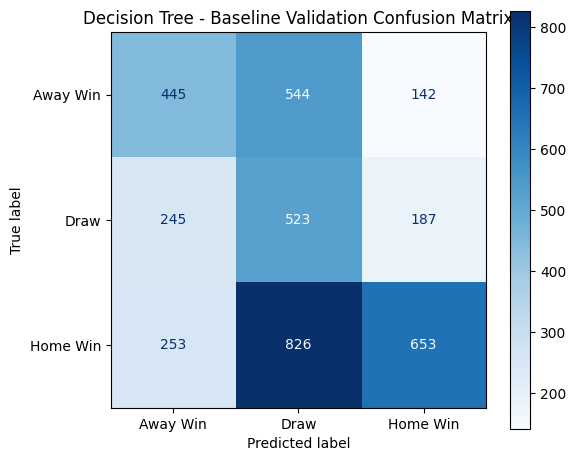

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_encoded,
    y_val_pred_base,
    display_labels=target_encoder.classes_,
    cmap="Blues",
    ax=ax
)
plt.title("Decision Tree - Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(DT_DIR, "baseline_confusion_matrix.png"), dpi=300)
plt.show()

BASELINE: train vs validation

In [10]:
y_train_proba_base = dt_baseline.predict_proba(X_train_dt)
y_train_pred_base = predict_with_draw_threshold(y_train_proba_base, base_threshold)

print("=" * 60)
print("BASELINE DECISION TREE")
print("=" * 60)
print(f"Draw threshold        : {base_threshold:.3f}")
print(f"Train Accuracy        : {accuracy_score(y_train_encoded, y_train_pred_base):.4f}")
print(f"Train Macro F1        : {f1_score(y_train_encoded, y_train_pred_base, average='macro'):.4f}")
print(f"Validation Accuracy   : {base_metrics['Accuracy']:.4f}")
print(f"Validation Macro F1   : {base_metrics['Macro F1']:.4f}")
print(f"Validation ROC-AUC    : {base_metrics['ROC-AUC']:.4f}")

print("\nBaseline Validation Report:")
print(classification_report(
    y_val_encoded,
    y_val_pred_base,
    target_names=target_encoder.classes_,
    zero_division=0)
)

BASELINE DECISION TREE
Draw threshold        : 0.360
Train Accuracy        : 0.4402
Train Macro F1        : 0.4416
Validation Accuracy   : 0.4246
Validation Macro F1   : 0.4259
Validation ROC-AUC    : 0.6522

Baseline Validation Report:
              precision    recall  f1-score   support

    Away Win       0.47      0.39      0.43      1131
        Draw       0.28      0.55      0.37       955
    Home Win       0.66      0.38      0.48      1732

    accuracy                           0.42      3818
   macro avg       0.47      0.44      0.43      3818
weighted avg       0.51      0.42      0.44      3818



Pipeline + Time-series Tuning

In [11]:
dt_pipeline = Pipeline([
    ("selector", RFE(DecisionTreeClassifier(**BASE_TREE_PARAMS),
                     n_features_to_select=DT_TARGET_FEATURES, step=0.10)),
    ("classifier", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

param_distributions = {
    "classifier__criterion":         ["gini", "entropy", "log_loss"],
    "classifier__max_depth":         [3, 4, 5, 6, 7, 8],
    "classifier__min_samples_split": [20, 40, 80, 120],
    "classifier__min_samples_leaf":  [20, 50, 100, 150, 200],
    "classifier__max_features":      [None, "sqrt", "log2", 0.5, 0.75],
    "classifier__ccp_alpha":         [0.0, 0.0001, 0.0005, 0.001, 0.005],
}

cv = TimeSeriesSplit(n_splits=5)

dt_random_search = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=param_distributions,
    n_iter=40, scoring="f1_macro", cv=cv,
    verbose=1, random_state=42, n_jobs=-1,
    refit=True, return_train_score=True
)
dt_random_search.fit(X_train_corr, y_train_encoded)

print("Best parameters:")
for k, v in dt_random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV Macro F1: {dt_random_search.best_score_:.4f}")

best_dt_pipeline = dt_random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters:
  classifier__min_samples_split: 40
  classifier__min_samples_leaf: 100
  classifier__max_features: 0.5
  classifier__max_depth: 4
  classifier__criterion: entropy
  classifier__ccp_alpha: 0.0
Best CV Macro F1: 0.4409


EVALUATION: threshold from validation only, test used once

In [12]:
y_val_proba_tuned = best_dt_pipeline.predict_proba(X_val_corr)

best_threshold = tune_draw_threshold(y_val_encoded, y_val_proba_tuned)

print(f"Calibrated Tuned Draw Threshold: {best_threshold:.3f}")

y_val_pred_tuned, val_metrics = evaluate(
    y_val_encoded,
    y_val_proba_tuned,
    best_threshold
)

y_test_proba = best_dt_pipeline.predict_proba(X_test_corr)

y_test_pred, test_metrics = evaluate(
    y_test_encoded,
    y_test_proba,
    best_threshold
)

comparison_df = pd.DataFrame({
    "Baseline Validation": base_metrics,
    "Tuned Validation": val_metrics,
    "Final Test": test_metrics
})
display(comparison_df.round(4))

print("\nTuned Validation Report:")
print(classification_report(
    y_val_encoded,
    y_val_pred_tuned,
    target_names=target_encoder.classes_,
    zero_division=0)
)

print("\nFinal Test Report:")
print(classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=target_encoder.classes_,
    zero_division=0)
)

Calibrated Tuned Draw Threshold: 0.360


,Baseline Validation,Tuned Validation,Final Test
Accuracy,0.4246,0.4678,0.4483
Macro Precision,0.4710,0.4710,0.4450
Macro Recall,0.4394,0.4580,0.4324
Macro F1,0.4259,0.4581,0.4345
Weighted F1,0.4373,0.4792,0.4571
ROC-AUC,0.6522,0.6559,0.6362
Argmax Accuracy,0.4369,0.4725,0.4545



Tuned Validation Report:
              precision    recall  f1-score   support

    Away Win       0.51      0.45      0.48      1131
        Draw       0.28      0.41      0.34       955
    Home Win       0.62      0.51      0.56      1732

    accuracy                           0.47      3818
   macro avg       0.47      0.46      0.46      3818
weighted avg       0.50      0.47      0.48      3818


Final Test Report:
              precision    recall  f1-score   support

    Away Win       0.48      0.41      0.44      1173
        Draw       0.27      0.37      0.31       980
    Home Win       0.58      0.52      0.55      1706

    accuracy                           0.45      3859
   macro avg       0.45      0.43      0.43      3859
weighted avg       0.47      0.45      0.46      3859



Baseline vs Tuned improvement

In [13]:
improvement = (comparison_df["Tuned Validation"] - comparison_df["Baseline Validation"]).rename("Improvement")
display(pd.concat([comparison_df[["Baseline Validation", "Tuned Validation"]], improvement], axis=1).round(4))

,Baseline Validation,Tuned Validation,Improvement
Accuracy,0.4246,0.4678,0.0432
Macro Precision,0.4710,0.4710,-0.0000
Macro Recall,0.4394,0.4580,0.0186
Macro F1,0.4259,0.4581,0.0322
Weighted F1,0.4373,0.4792,0.0419
ROC-AUC,0.6522,0.6559,0.0036
Argmax Accuracy,0.4369,0.4725,0.0356


TUNED: train vs validation

In [14]:
y_train_proba_tuned = best_dt_pipeline.predict_proba(X_train_corr)
y_train_pred_tuned = predict_with_draw_threshold(y_train_proba_tuned, best_threshold)

print("=" * 60)
print("TUNED DECISION TREE")
print("=" * 60)
print(f"Train Macro F1      : {f1_score(y_train_encoded, y_train_pred_tuned, average='macro'):.4f}")
print(f"Validation Macro F1 : {val_metrics['Macro F1']:.4f}")
print(f"CV Macro F1         : {dt_random_search.best_score_:.4f}")

TUNED DECISION TREE
Train Macro F1      : 0.4502
Validation Macro F1 : 0.4581
CV Macro F1         : 0.4409


Majority Baseline + Predicted VS Actual

In [15]:
maj = y_train_encoded.value_counts().idxmax()
print("Majority baseline accuracy:",
      round(accuracy_score(y_test_encoded, np.full(len(y_test_encoded), maj)), 4))

dist = pd.DataFrame({
    "Actual": pd.Series(y_test_encoded).value_counts(normalize=True).sort_index(),
    "Predicted": pd.Series(y_test_pred).value_counts(normalize=True).sort_index(),
})
dist.index = target_encoder.classes_
display((dist * 100).round(2))

Majority baseline accuracy: 0.4421


,Actual,Predicted
Away Win,30.40,25.68
Draw,25.40,34.75
Home Win,44.21,39.57


Confusion Matrices

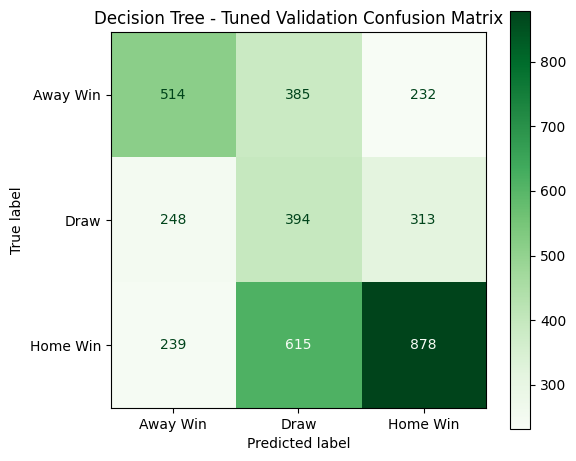

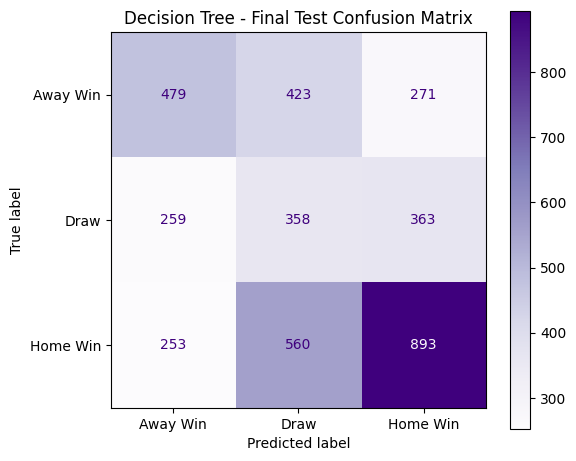

In [16]:
for name, y_t, y_p, cmap, fn in [
    ("Tuned Validation", y_val_encoded, y_val_pred_tuned,
     "Greens",
     "tuned_validation_confusion_matrix.png"),

    ("Final Test", y_test_encoded, y_test_pred,
     "Purples",
     "final_test_confusion_matrix.png"),
]:
    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_t, y_p,
        display_labels=target_encoder.classes_,
        cmap=cmap,
        ax=ax
    )

    plt.title(f"Decision Tree - {name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(DT_DIR, fn), dpi=300)
    plt.show()

Feature Importance

,Feature,Importance
0,elo_difference,0.569184
1,goals_for_difference,0.304546
2,home_elo_before,0.071975
3,venue_win_rate_difference,0.018947
4,away_away_win_rate,0.011405
5,win_rate_difference,0.008910
6,away_win_rate,0.008812
7,home_goals_against_per_match,0.006221
8,home_home_goals_against_per_match,0.000000
9,home_home_draw_rate,0.000000


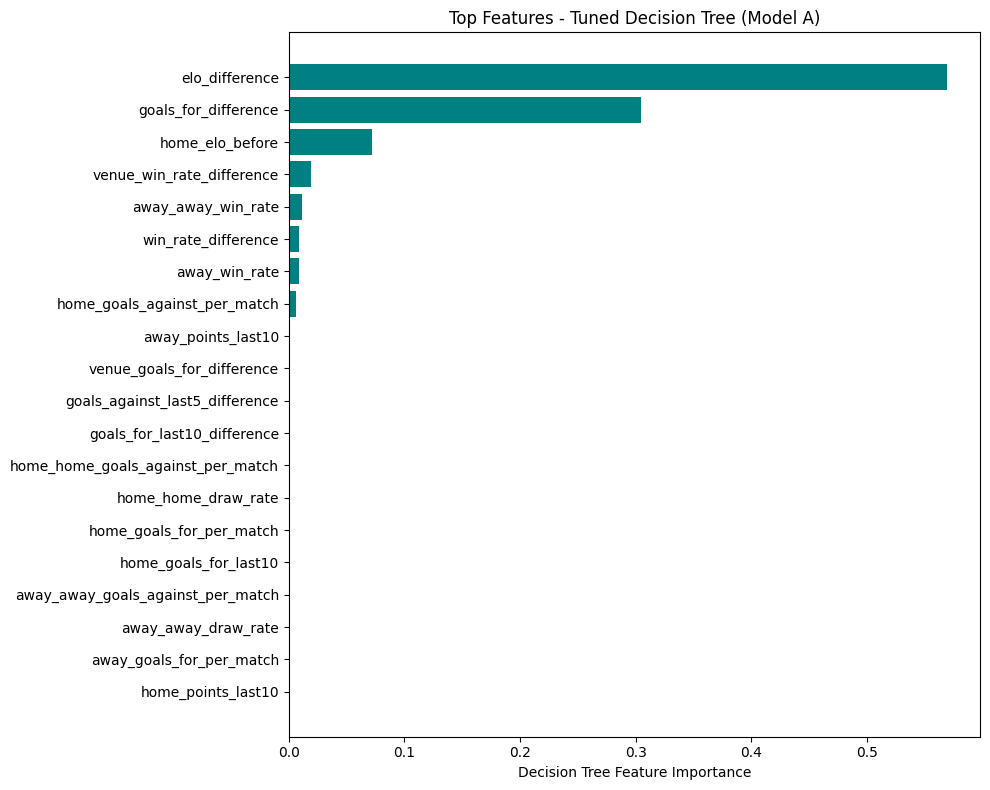

In [17]:
final_selector = best_dt_pipeline.named_steps["selector"]
final_classifier = best_dt_pipeline.named_steps["classifier"]
final_dt_features = X_train_corr.columns[final_selector.get_support()].tolist()

feature_importance_df = pd.DataFrame({
    "Feature": final_dt_features,
    "Importance": final_classifier.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)
display(feature_importance_df.head(20))

top = feature_importance_df.head(20).sort_values("Importance")
plt.figure(figsize=(10, 8))
plt.barh(top["Feature"], top["Importance"], color="teal")
plt.xlabel("Decision Tree Feature Importance")
plt.title("Top Features - Tuned Decision Tree (Model A)")
plt.tight_layout()
plt.savefig(os.path.join(DT_DIR, "decision_tree_feature_importances.png"), dpi=300)
plt.show()

Save Outputs

In [18]:
X_train_corr[final_dt_features].to_csv(os.path.join(
    DT_DIR, "X_train_dt_selected.csv"
), index=False)

X_val_corr[final_dt_features].to_csv(os.path.join(
    DT_DIR, "X_validation_dt_selected.csv"
), index=False)

X_test_corr[final_dt_features].to_csv(
    os.path.join(DT_DIR, "X_test_dt_selected.csv"
), index=False)

joblib.dump(best_dt_pipeline, os.path.join
 (DT_DIR, "decision_tree_tuned_pipeline.joblib")
)

joblib.dump(final_selector, os.path.join
 (DT_DIR, "dt_feature_selector.joblib")
)

joblib.dump(corr_drop_columns, os.path.join(
    DT_DIR, "correlation_dropped_columns.joblib")
)

joblib.dump(final_dt_features, os.path.join(
    DT_DIR, "decision_tree_selected_features.joblib")
)

joblib.dump(best_threshold, os.path.join(
    DT_DIR, "calibrated_draw_threshold.joblib")
)

pd.DataFrame({"Feature": final_dt_features}).to_csv(
    os.path.join(
        DT_DIR,
        "decision_tree_selected_features.csv"
    ), index=False
)

comparison_df.to_csv(os.path.join(
    DT_DIR, "decision_tree_results.csv")
)

feature_importance_df.to_csv(os.path.join(
    DT_DIR, "decision_tree_feature_importance.csv"
), index=False)

pd.DataFrame(dt_random_search.cv_results_).to_csv(
    os.path.join(
        DT_DIR,
        "decision_tree_cv_results.csv"
    ), index=False)

print("Decision Tree outputs saved to:", DT_DIR)

Decision Tree outputs saved to: /content/drive/MyDrive/ML Assignment/decision_tree
